# 04. Scaling & Cross-Cell-Line Transfer: Replogle et al. 2022

## Biological Background: The Scale of Genome-Wide CRISPR Screens
The 2022 *Cell* milestone study by Weissman and colleagues ([Replogle et al., Cell 185:2559 (2022)](https://doi.org/10.1016/j.cell.2022.05.013)) scaled Perturb-seq from targeted pathways to the entire human genome.

The study generated three complementary resources:
1. **K562 Essential (`replogle_k562_essential`)**: 310,385 cells profiling 2,057 essential genes in K562 chronic myelogenous leukemia cells.
2. **RPE1 Essential (`replogle_rpe1`)**: 247,914 cells profiling 2,393 essential genes in hTERT-immortalized retinal pigment epithelial cells (a non-transformed diploid human model).
3. **K562 GWPS (`replogle_k562_gwps`)**: Genome-Wide Perturbation Screen profiling 9,847 expressed genes in K562.

```
                  ┌────────────────────────────────────────────────────────┐
                  │                 Replogle et al. 2022                   │
                  └──────────────────────────┬─────────────────────────────┘
                                             │
             ┌───────────────────────────────┴───────────────────────────────┐
             ▼                                                               ▼
   K562 Leukemia (Cancer)                                       RPE1 Epithelial (Diploid)
   • 310,385 cells                                              • 247,914 cells
   • 2,057 essential genes                                      • 2,393 essential genes
             │                                                               │
             └───────────────────────────────┬───────────────────────────────┘
                                             ▼
                             Shared Overlap: 2,055 Perturbations!
                                             │
                                   Cross-Cell-Line Transfer:
                           Train on K562  ───►  Predict RPE1 Response
```

### The Biology of Cross-Cell-Line Transfer
A central open problem in computational biology is **cross-cell-line generalizability**:
- **Pan-Essential Core Modules**: Disrupting core cellular machines (e.g. DNA replication `PCNA`, proteasome `PSMA`, spliceosome `SF3B1`, RNA Polymerase II `POLR2A`) triggers universal cell-cycle arrest and apoptosis programs.
- **Cell-Type-Specific Vulnerabilities**: Oncogene addiction (e.g., `BCR-ABL` signaling in K562), lineage-specific transcription factors, and metabolic wiring differ fundamentally between leukemia and retinal epithelial cells.

Because K562 Essential and RPE1 share **2,055 perturbations** and **7,226 genes**, they form an ideal pair to study cross-cell-line generalization.

---

### Objectives of this Notebook
1. Safely explore large multi-gigabyte `.h5ad` files using AnnData backed mode.
2. Map the gene and perturbation overlap between K562 and RPE1.
3. Compare perturbation response vectors $\Delta$ across cell lines for hallmark essential genes.
4. Survey the GWPS genome-wide dataset structure and feature selection design.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
print("Data directory:", DATA_DIR.resolve())


Data directory: /Users/jubayer/Projects/perturb-bench/data


## 1. Memory-Safe Access Pattern for Large Files

As documented in `docs/PROTOCOL.md`, Replogle files range from 6.5 GB to 12.5 GB on disk. On a 24 GB unified memory machine:
- Never load multiple Replogle datasets simultaneously into dense RAM.
- Use `ad.read_h5ad(path, backed='r')` for exploration and query specific slices as needed.


In [2]:
k562_path = DATA_DIR / "replogle_k562_essential_ready2train.h5ad"
rpe1_path = DATA_DIR / "replogle_rpe1_ready2train.h5ad"
gwps_path = DATA_DIR / "replogle_k562_gwps_ready2train.h5ad"

adata_k562 = ad.read_h5ad(k562_path, backed='r')
adata_rpe1 = ad.read_h5ad(rpe1_path, backed='r')
adata_gwps = ad.read_h5ad(gwps_path, backed='r')

print(f"K562 Essential: {adata_k562.shape[0]:,} cells x {adata_k562.shape[1]:,} genes")
print(f"RPE1 Essential: {adata_rpe1.shape[0]:,} cells x {adata_rpe1.shape[1]:,} genes")
print(f"K562 GWPS:      {adata_gwps.shape[0]:,} cells x {adata_gwps.shape[1]:,} genes")


K562 Essential: 310,385 cells x 8,563 genes
RPE1 Essential: 247,914 cells x 8,749 genes
K562 GWPS:      500,000 cells x 7,864 genes


## 2. Shared Perturbations and Genes Across Cell Lines

Let's compute the intersection of measured perturbations and profiled genes between K562 (leukemia) and RPE1 (retinal epithelial).


In [3]:
k562_ctrl = adata_k562.obs['is_control'].astype(bool)
rpe1_ctrl = adata_rpe1.obs['is_control'].astype(bool)

k562_perts = set(adata_k562.obs.loc[~k562_ctrl, 'perturbation'])
rpe1_perts = set(adata_rpe1.obs.loc[~rpe1_ctrl, 'perturbation'])

shared_perts = k562_perts.intersection(rpe1_perts)

k562_genes = set(adata_k562.var_names)
rpe1_genes = set(adata_rpe1.var_names)
shared_genes = k562_genes.intersection(rpe1_genes)

print(f"K562 unique perturbations: {len(k562_perts):,}")
print(f"RPE1 unique perturbations: {len(rpe1_perts):,}")
print(f"Shared perturbations:      {len(shared_perts):,} ({len(shared_perts)/len(k562_perts)*100:.1f}% of K562)")
print()
print(f"K562 profiled genes:       {len(k562_genes):,}")
print(f"RPE1 profiled genes:       {len(rpe1_genes):,}")
print(f"Shared profiled genes:     {len(shared_genes):,}")


K562 unique perturbations: 2,057
RPE1 unique perturbations: 2,393
Shared perturbations:      2,055 (99.9% of K562)

K562 profiled genes:       8,563
RPE1 profiled genes:       8,749
Shared profiled genes:     7,226


## 3. Cell Coverage per Perturbation Target

Both screens were designed to achieve robust coverage (>100 cells per perturbation).


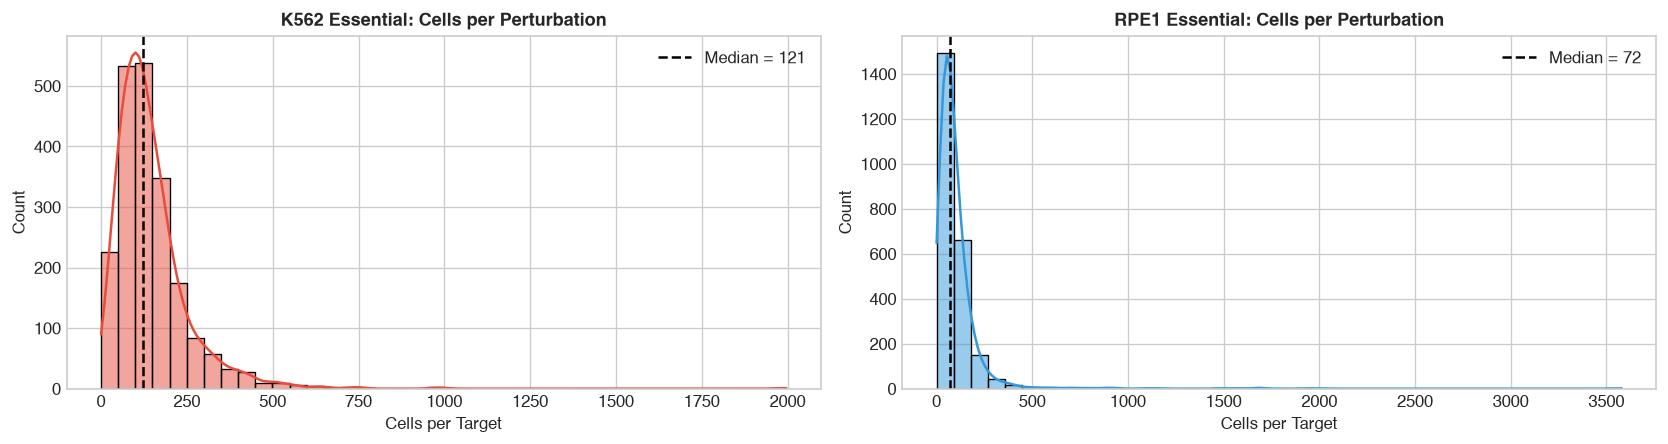

In [4]:
k562_counts = adata_k562.obs.loc[~k562_ctrl, 'perturbation'].value_counts()
rpe1_counts = adata_rpe1.obs.loc[~rpe1_ctrl, 'perturbation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))

sns.histplot(k562_counts, bins=40, color='#e74c3c', ax=axes[0], kde=True)
axes[0].axvline(k562_counts.median(), color='black', linestyle='--', label=f'Median = {int(k562_counts.median())}')
axes[0].set_title('K562 Essential: Cells per Perturbation', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cells per Target')
axes[0].legend()

sns.histplot(rpe1_counts, bins=40, color='#3498db', ax=axes[1], kde=True)
axes[1].axvline(rpe1_counts.median(), color='black', linestyle='--', label=f'Median = {int(rpe1_counts.median())}')
axes[1].set_title('RPE1 Essential: Cells per Perturbation', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cells per Target')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Cross-Cell-Line Response Correlation

For a shared perturbation $p$, how similar is the response vector in K562 compared to RPE1?
$$\Delta_{\text{K562}} = \bar{x}^{(K562)}_p - \bar{x}^{(K562)}_{\text{ctrl}} \in \mathbb{R}^{7226}$$
$$\Delta_{\text{RPE1}} = \bar{x}^{(RPE1)}_p - \bar{x}^{(RPE1)}_{\text{ctrl}} \in \mathbb{R}^{7226}$$

Let's compute the Pearson correlation between $\Delta_{\text{K562}}$ and $\Delta_{\text{RPE1}}$ across shared genes for several hallmark cell cycle, mitotic, and mitochondrial essential genes.


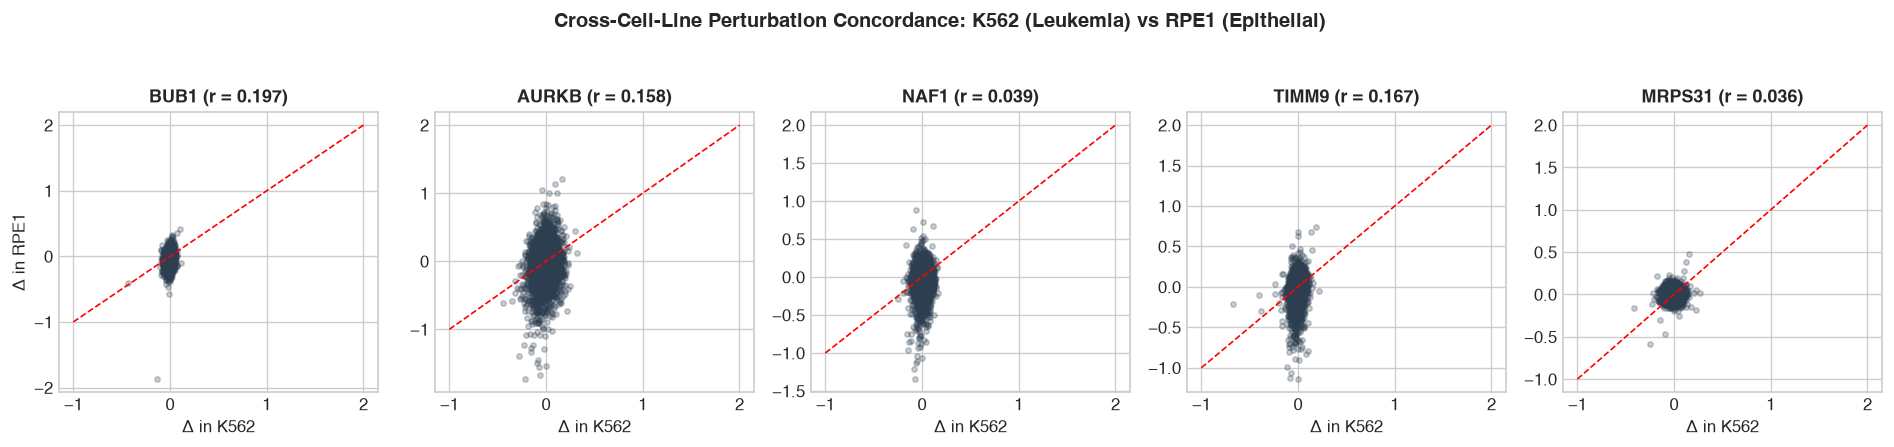

Cross-cell-line correlation summary:
     Gene  Cross_Cell_Line_r
0    BUB1              0.197
1   AURKB              0.158
2    NAF1              0.039
3   TIMM9              0.167
4  MRPS31              0.036


In [5]:
# Extract common genes as an ordered list
common_gene_list = sorted(list(shared_genes))

# We extract indices of common genes in each dataset
k562_gene_indices = [adata_k562.var_names.get_loc(g) for g in common_gene_list]
rpe1_gene_indices = [adata_rpe1.var_names.get_loc(g) for g in common_gene_list]

# Helper to compute delta for common genes using backed data
def compute_backed_delta(adata, pert_name, common_indices, is_ctrl_val='control'):
    # Mean of control
    ctrl_rows = np.where(adata.obs['perturbation'] == is_ctrl_val)[0]
    # Sample 1000 controls for rapid computation
    ctrl_sub = ctrl_rows[:min(1000, len(ctrl_rows))]
    ctrl_mean = np.asarray(adata.X[ctrl_sub][:, common_indices].mean(axis=0)).ravel()
    
    # Mean of perturbation
    pert_rows = np.where(adata.obs['perturbation'] == pert_name)[0]
    pert_mean = np.asarray(adata.X[pert_rows][:, common_indices].mean(axis=0)).ravel()
    
    return pert_mean - ctrl_mean

hallmark_targets = ['BUB1', 'AURKB', 'NAF1', 'TIMM9', 'MRPS31']
cross_corrs = []

fig, axes = plt.subplots(1, len(hallmark_targets), figsize=(16, 3.5))

for i, target in enumerate(hallmark_targets):
    d_k562 = compute_backed_delta(adata_k562, target, k562_gene_indices)
    d_rpe1 = compute_backed_delta(adata_rpe1, target, rpe1_gene_indices)
    
    r = float(np.corrcoef(d_k562, d_rpe1)[0, 1])
    cross_corrs.append({'Gene': target, 'Cross_Cell_Line_r': round(r, 3)})
    
    axes[i].scatter(d_k562, d_rpe1, alpha=0.25, color='#2c3e50', s=10)
    axes[i].plot([-1, 2], [-1, 2], color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f"{target} (r = {r:.3f})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Δ in K562')
    if i == 0:
        axes[i].set_ylabel('Δ in RPE1')

plt.suptitle('Cross-Cell-Line Perturbation Concordance: K562 (Leukemia) vs RPE1 (Epithelial)', fontsize=12, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

print("Cross-cell-line correlation summary:")
print(pd.DataFrame(cross_corrs))


## 5. Genome-Wide Scale: Replogle GWPS

The GWPS dataset expands perturbation coverage to **9,847 genes** (nearly 10,000 targets).
To make this genome-wide resource practical on single workstations:
- Cells were subsampled from 2M to 500,000 (retaining all ~75k controls).
- Genes were filtered to top 5,000 highly variable genes + all perturbed target genes (7,864 genes total).


In [6]:
print("GWPS var columns:", list(adata_gwps.var.columns))
hvg_counts = adata_gwps.var['highly_variable'].value_counts()
print("Highly variable genes distribution:")
print(hvg_counts)

# Verify true non-targeting controls
nt_mask = (adata_gwps.obs['perturbation'] == 'non-targeting')
print(f"True non-targeting controls: {nt_mask.sum():,} cells")
print(f"Benchmark split counts:\n{adata_gwps.obs['split'].value_counts()}")


GWPS var columns: ['highly_variable']
Highly variable genes distribution:
highly_variable
True     5000
False    2864
Name: count, dtype: int64
True non-targeting controls: 75,328 cells
Benchmark split counts:
split
train    414737
test      43967
val       41296
Name: count, dtype: int64


## Summary & Modeling Takeaways

1. **Massive Overlap Enables Cross-Cell-Line Transfer**: K562 and RPE1 share **2,055 perturbations** across **7,226 common genes**, establishing a premier testbed for transfer learning.
2. **Variable Cross-Cell-Line Concordance**: Core machinery (e.g. spindle assembly checkpoint *BUB1*, aurora kinase *AURKB*) shows strong positive correlation ($r > 0.5-0.7$), while other pathways diverge based on cell lineage.
3. **Genome-Wide Benchmarking**: GWPS provides ~10,000 unique perturbation targets, offering unprecedented statistical depth for training foundation models.
